<a href="https://colab.research.google.com/github/shadyessam1/ai-cyber-lab/blob/main/notebooks/01_fastai_lesson1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install -Uqq fastai ddgs

In [11]:
from fastai.vision.all import *
from fastdownload import download_url
from time import sleep

try:
    from ddgs import DDGS
except ImportError:
    from duckduckgo_search import DDGS

def search_images(term, max_images=200):
    print(f"Searching for '{term}'")
    results = DDGS().images(term, max_results=max_images)
    return L([r['image'] for r in results])

Searching for 'bird photos'
https://images.pexels.com/photos/326900/pexels-photo-326900.jpeg?cs=srgb&dl=wood-flight-bird-326900.jpg&fm=jpg


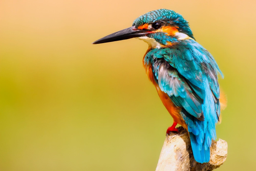

In [12]:
urls = search_images('bird photos', max_images=1)
print(urls[0])
download_url(urls[0], 'bird.jpg', show_progress=False)
Image.open('bird.jpg').to_thumb(256, 256)

In [13]:
searches = 'forest', 'bird'
path = Path('data/bird_or_not')

for o in searches:
    dest = path/o
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo'))
    sleep(10)
    resize_images(path/o, max_size=400, dest=path/o)

Searching for 'forest photo'
Searching for 'bird photo'


In [14]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
print(f'Removed {len(failed)} broken images')
for o in searches:
    print(o, len(get_image_files(path/o)))

Removed 0 broken images
forest 63
bird 65


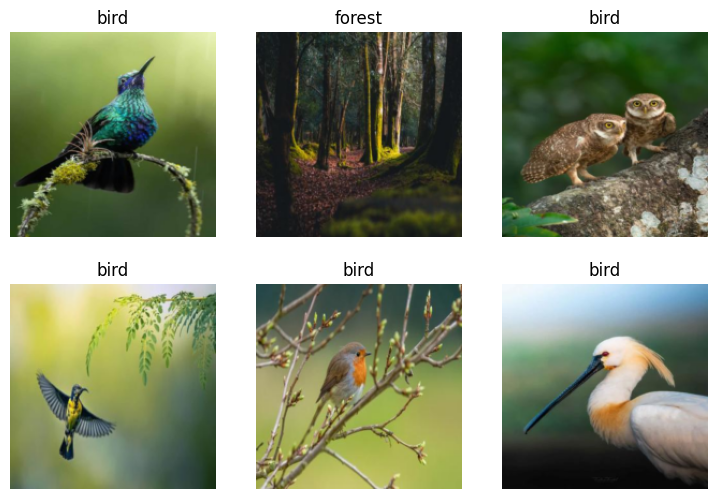

In [15]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)


In [16]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,1.080736,0.214406,0.160000,00:01


epoch,train_loss,valid_loss,error_rate,time
0,0.075106,0.099726,0.040000,00:01
1,0.042350,0.220946,0.080000,00:01
2,0.028519,0.275137,0.080000,00:01


In [17]:
err = learn.validate()[1]
print(f'Validation accuracy: {1 - err:.4f}')
print(f'Train: {len(dls.train_ds)} | Valid: {len(dls.valid_ds)}')

Validation accuracy: 0.9200
Train: 103 | Valid: 25


In [18]:
is_bird, _, probs = learn.predict(PILImage.create('bird.jpg'))
print(f'This is a: {is_bird}. Probability: {probs[0]:.4f}')

This is a: bird. Probability: 1.0000
